In [29]:
import tensorflow as tf

import numpy as np

import matplotlib.pyplot as plt

from PIL import Image

In [30]:
MODEL_PATH = "/workspaces/plant_disease_detection/artifacts/final_plant_disease_model.keras"

model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded successfully!")

Model loaded successfully!


In [18]:
DATASET_PATH = "/workspaces/plant_disease_detection/data/raw"

dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

class_names = dataset.class_names

print(class_names)

Found 20638 files belonging to 15 classes.
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [31]:
predicted_index = np.argmax(predictions)

print("Predicted Index:", predicted_index)

print("Predicted Class:", class_names[predicted_index])

Predicted Index: 7
Predicted Class: Tomato_Late_blight


In [32]:
top_5_indices = np.argsort(predictions[0])[-5:][::-1]

for idx in top_5_indices:
    print(
        f"{class_names[idx]} : {predictions[0][idx]*100:.2f}%"
    )

Tomato_Late_blight : 99.99%
Tomato_Early_blight : 0.01%
Pepper__bell___Bacterial_spot : 0.00%
Tomato_Leaf_Mold : 0.00%
Tomato_Spider_mites_Two_spotted_spider_mite : 0.00%


In [33]:
IMG_HEIGHT = 224
IMG_WIDTH = 224

In [34]:
def preprocess_image(image_path):

    img = Image.open(image_path)

    img = img.resize((IMG_WIDTH, IMG_HEIGHT))

    img = np.array(img)

    img = img / 255.0

    img = np.expand_dims(img, axis=0)

    return img

In [35]:
IMAGE_PATH = "/workspaces/plant_disease_detection/data/raw/Pepper__bell___healthy/9d74f9ff-7c49-4210-93f8-99b2be15aaad___JR_HL 8366.JPG"

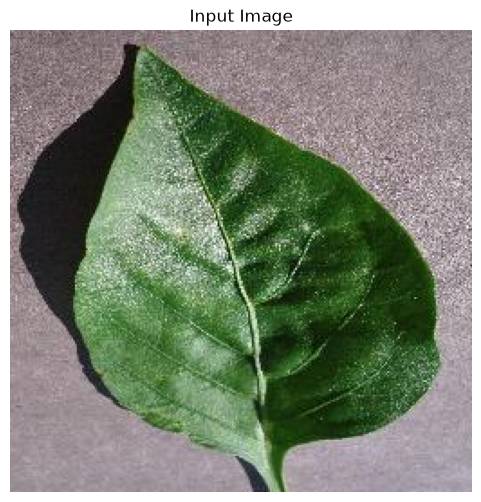

In [36]:
img = Image.open(IMAGE_PATH)

plt.figure(figsize=(6,6))

plt.imshow(img)

plt.title("Input Image")

plt.axis("off")

plt.show()

In [37]:
processed_image = preprocess_image(
    IMAGE_PATH
)

print(processed_image.shape)

(1, 224, 224, 3)


In [38]:
predictions = model.predict(
    processed_image
)

print(predictions.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
(1, 15)


In [39]:
predicted_index = np.argmax(
    predictions
)

predicted_class = class_names[
    predicted_index
]

print("Predicted Disease:")
print(predicted_class)

Predicted Disease:
Tomato_Late_blight


In [21]:
import os

folder = "/workspaces/plant_disease_detection/data/raw/Pepper__bell___healthy"

images = os.listdir(folder)

print(images[:10])

['9d74f9ff-7c49-4210-93f8-99b2be15aaad___JR_HL 8366.JPG', '4ea8bfc8-c0fb-4206-9630-171c91cd7bb3___JR_HL 7838.JPG', 'bc388512-fc59-4069-bae0-05faca671d1e___JR_HL 8362.JPG', '0e5d9ac1-4de8-491e-ab95-809850866805___JR_HL 8534.JPG', '8a5ccd09-d957-4522-ae9e-54a101e569e8___JR_HL 8543.JPG', '3b8c55fd-ddd6-4ab6-94e8-3be93b1728eb___JR_HL 5963.JPG', 'a558bc8d-6d5b-42d0-b9b5-c3cb34d60b54___JR_HL 8583.JPG', '365b9977-fab1-4a4b-9807-605151f9db3e___JR_HL 7766.JPG', 'a78a9a04-3ff9-44b2-bf18-58d5dc301014___JR_HL 8633.JPG', 'ffd8d1a7-1596-4c8a-bd05-1e284b8cfaa5___JR_HL 8266.JPG']


In [40]:
confidence = np.max(predictions)

print(
    f"Confidence: {confidence*100:.2f}%"
)

Confidence: 99.99%


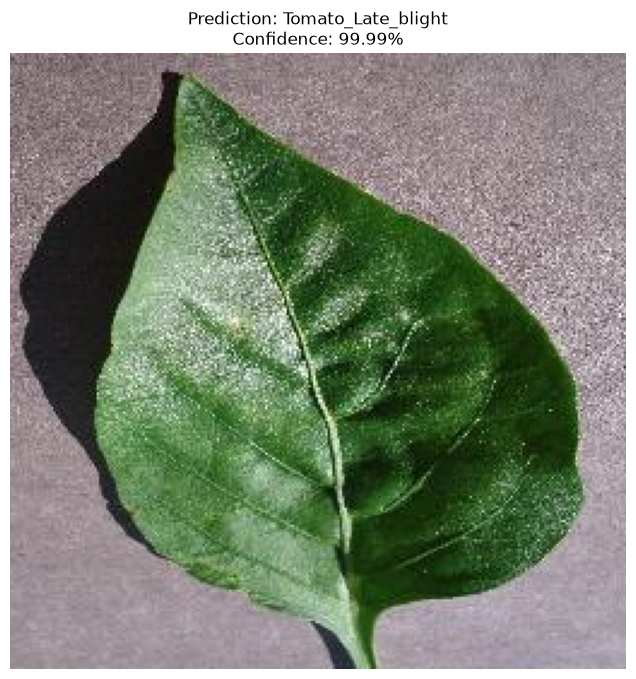

In [41]:
img = Image.open(IMAGE_PATH)

plt.figure(figsize=(8,8))

plt.imshow(img)

plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence*100:.2f}%"
)

plt.axis("off")

plt.show()